# Лабораторная работа №2, вариант 8

### Цель работы: изучить программные средства, используемые для визуализации наборов данных. 

Вариант 8 – Обнаружение нестабильной электрической сети 
Датасет – electrical_grid.csv 
Цель состоит в том, чтобы понимать и планировать как нарушения, так и колеба
ния производства и/или потребления энергии, вносимые участниками системы, дина
мическим образом, принимая во внимание не только технические аспекты, но и то, 
как участники реагируют на изменения в связанных с ними экономических аспектах 
(стоимость энергии). 
Набор данных содержит 10 000 наблюдений. Он также содержит 12 основных 
прогностических признаков и зависимую переменную. 
• Прогностические функции: 
tau1 – tau4: время реакции каждого участника сети, действительное значение в 
диапазоне от 0,5 до 10 (tau1 соответствует узлу-поставщику, tau2 – tau4 – узлам-по
требителям); 
p1 до'p4: номинальная мощность, произведенная (положительная) или потреб
ленная (отрицательная) каждым участником сети, реальное значение в диапазоне от 
2,0 до -0,5 для потребителей (p2 до p4). Поскольку общая потребляемая мощность 
равна общей генерируемой мощности, p1 (узел-поставщик) = - (p2 + p3 + p4); 
g1 – g4: коэффициент ценовой эластичности для каждого участника сети, дей
ствительное значение в диапазоне от 0,05 до 1,00 (g1 соответствует узлу-поставщику, 
g2 – g4 – узлам-потребителям; g означает гамма); 
• Зависимая переменная: 
stabf: категориальная (бинарная) метка («стабильный» или «нестабильный»). 

**1. Импортируйте необходимые библиотеки**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**2. Импортируйте набор данных из файла electrical_grid.csv и поместите его в DataFrame**

In [2]:
df = pd.read_csv('electrical_grid.csv')
df.head(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,unstable


**3. Получим сводную информацию по датафрейму**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stabf   10000 non-null  object 
dtypes: float64(12), object(1)
memory usage: 1015.8+ KB


**4. Визуализация количественных признаков**

Гистограмма распределения времени реакции узла-поставщика (tau1)
Показывает частоту встречаемости различных значений времени реакции, оценить форму распределения, определить наиболе типичные значения.

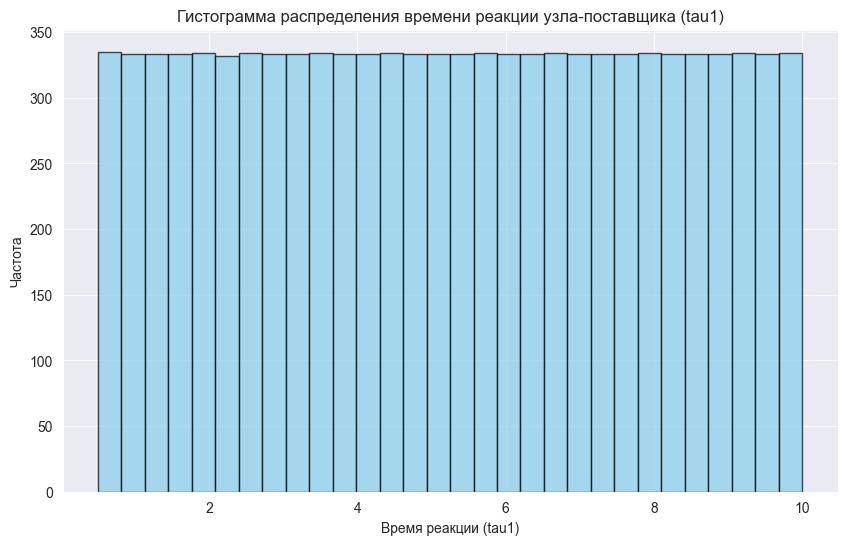

In [4]:
plt.figure(figsize=(10, 6))
df['tau1'].hist(bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Гистограмма распределения времени реакции узла-поставщика (tau1)')
plt.xlabel('Время реакции (tau1)')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

Матрица гистограмм всех числовых признаков
Представляет собой совокупность гистограмм для всех числовых переменных в наборе данных.

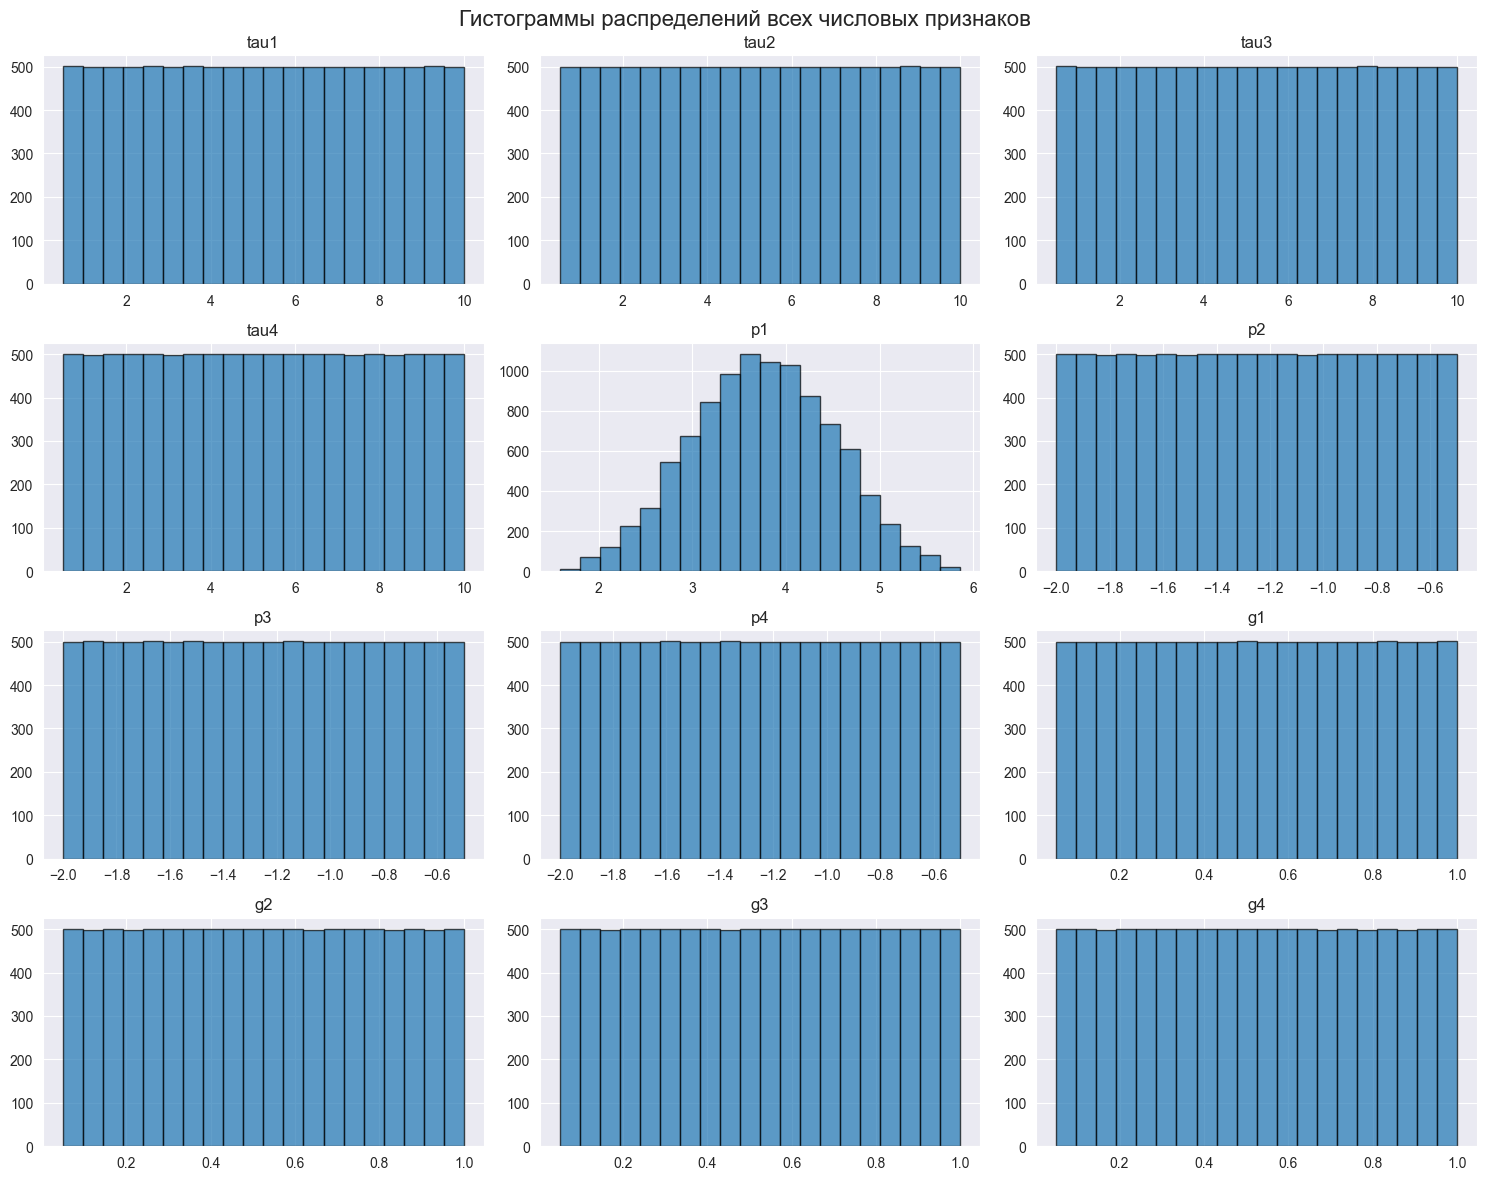

In [5]:
numerical_columns = df.select_dtypes(include=[np.number]).columns
df[numerical_columns].hist(figsize=(15, 12), bins=20, edgecolor='black', alpha=0.7)
plt.suptitle('Гистограммы распределений всех числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

Ящик с усами для времени реакции узла-поставщика (tau1)
Отображает основные статистические характеристики распределения: медиану, квартили и выбросы. Выбросы, отображаемые точками, не наблюдаются.

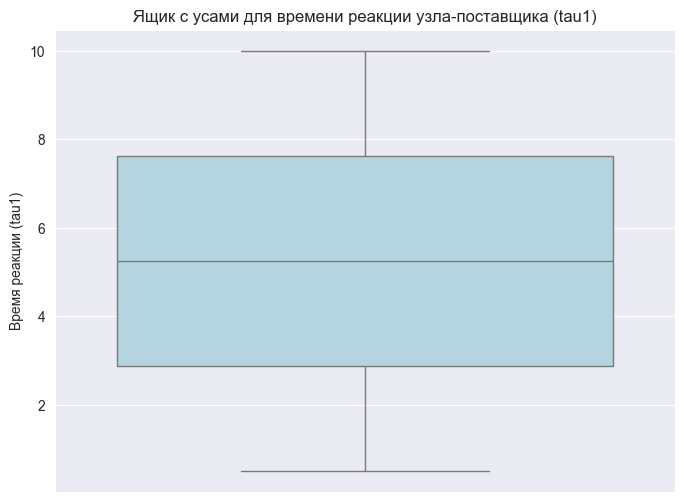

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='tau1', color='lightblue')
plt.title('Ящик с усами для времени реакции узла-поставщика (tau1)')
plt.ylabel('Время реакции (tau1)')
plt.show()

Матрица ящиков с усами для всех числовых признаков
Обеспечивает сравнительный анализ распределений всех числовых переменных. Выбросы, отображаемые точками, наблюдаются для p1 (Номинальная мощность узла-поставщика)

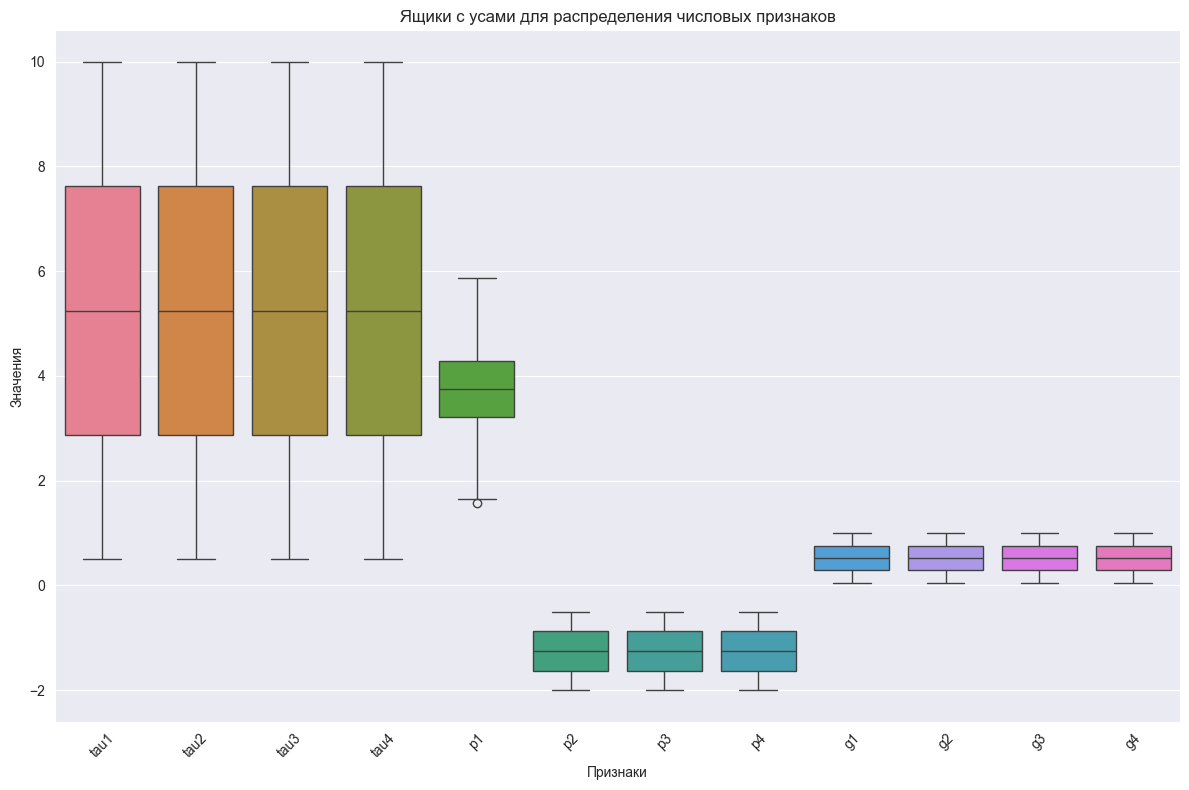

In [7]:
plt.figure(figsize=(12, 8))
numerical_data = df.select_dtypes(include=[np.number])
sns.boxplot(data=numerical_data)
plt.title('Ящики с усами для распределения числовых признаков')
plt.xlabel('Признаки')
plt.ylabel('Значения')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**5. Визуализация категориальных признаков**

Диаграмма распределения стабильности электрической сети
Столбчатая диаграмма отображает частоту встречаемости стабильных и нестабильных состояний системы. "stable" (стабильно) и "unstable" (нестабильно). Перевес в сторону нестабильности.

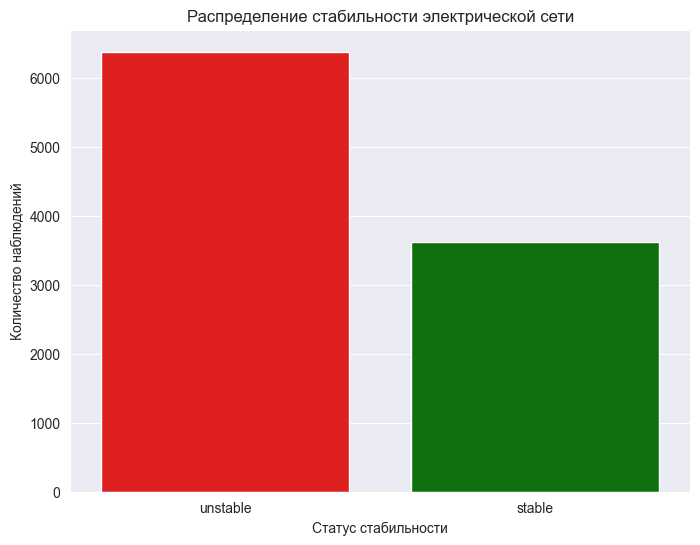

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='stabf', hue='stabf', palette=['red', 'green'], legend=False)
plt.title('Распределение стабильности электрической сети')
plt.xlabel('Статус стабильности')
plt.ylabel('Количество наблюдений')
plt.show()

Столбчатая диаграмма средних значений коэффициентов ценовой эластичности
Представляет средние значения коэффициентов эластичности спроса по ценам для четырех узлов сети (g1, g2, g3, g4). Средние значения коэффициентов эластичности для всех узлов одинаковы и равны 0.525.

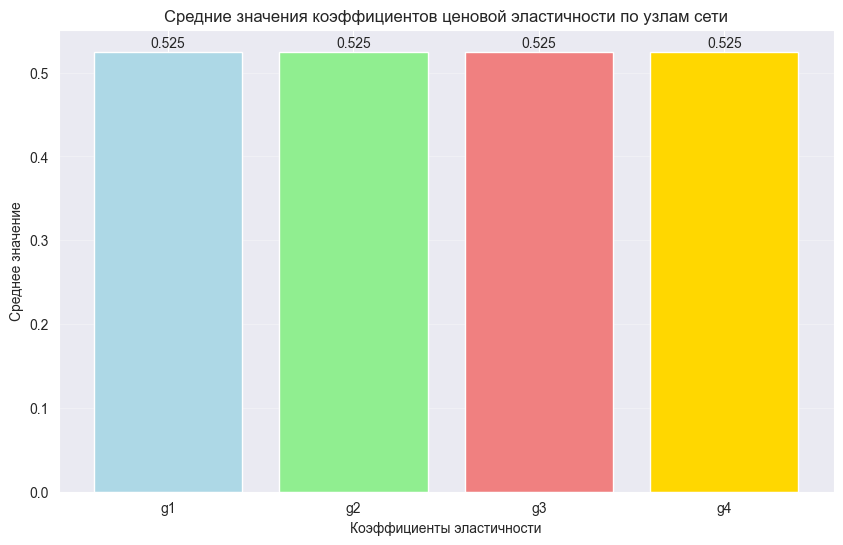

In [9]:
elasticity_features = ['g1', 'g2', 'g3', 'g4']
mean_elasticity = df[elasticity_features].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(elasticity_features, mean_elasticity.values,
               color=['lightblue', 'lightgreen', 'lightcoral', 'gold'])
plt.title('Средние значения коэффициентов ценовой эластичности по узлам сети')
plt.xlabel('Коэффициенты эластичности')
plt.ylabel('Среднее значение')

for bar, value in zip(bars, mean_elasticity.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{value:.3f}', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.show()

**6. Визуализация взаимосвязанных признаков**

Сравнительный анализ распределений ключевых признаков по стабильности сети
Представляет три параллельных графика "ящик с усами", позволяющих сравнить распределения времени реакции, номинальной мощности и коэффициента ценовой эластичности узла-поставщика между стабильными и нестабильными состояниями сети.

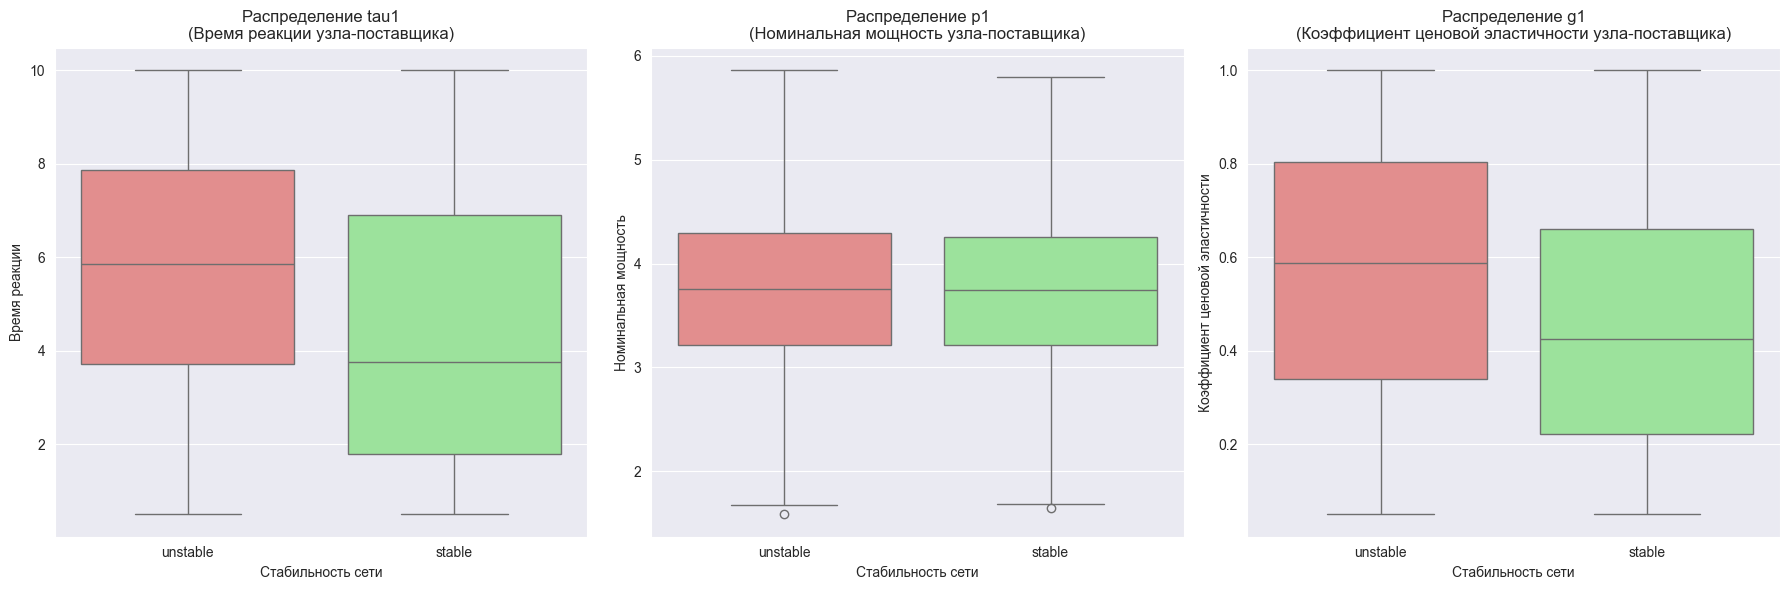

In [13]:
def get_feature_russian_name(feature):
    """
    ВОЗВРАЩАЕТ РУССКОЕ ОПИСАНИЕ ПРИЗНАКА ДЛЯ ПОДПИСЕЙ НА ГРАФИКАХ
    """
    feature_descriptions = {
        'tau1': 'Время реакции узла-поставщика',
        'tau2': 'Время реакции узла-потребителя 1',
        'tau3': 'Время реакции узла-потребителя 2',
        'tau4': 'Время реакции узла-потребителя 3',
        'p1': 'Номинальная мощность узла-поставщика',
        'p2': 'Номинальная мощность узла-потребителя 1',
        'p3': 'Номинальная мощность узла-потребителя 2',
        'p4': 'Номинальная мощность узла-потребителя 3',
        'g1': 'Коэффициент ценовой эластичности узла-поставщика',
        'g2': 'Коэффициент ценовой эластичности узла-потребителя 1',
        'g3': 'Коэффициент ценовой эластичности узла-потребителя 2',
        'g4': 'Коэффициент ценовой эластичности узла-потребителя 3',
        'stabf': 'Стабильность сети'
    }
    return feature_descriptions.get(feature, feature)

comparison_features = ['tau1', 'p1', 'g1']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(comparison_features):
    sns.boxplot(data=df, x='stabf', y=feature, hue='stabf', ax=axes[i],
                palette={'stable': 'lightgreen', 'unstable': 'lightcoral'},
                legend=False) 
    
    # Устанавливаем подписи осей
    if feature.startswith('tau'):
        axes[i].set_ylabel('Время реакции')
    elif feature.startswith('p'):
        axes[i].set_ylabel('Номинальная мощность')
    elif feature.startswith('g'):
        axes[i].set_ylabel('Коэффициент ценовой эластичности')

    axes[i].set_xlabel('Стабильность сети')
    feature_name = get_feature_russian_name(feature)
    axes[i].set_title(f'Распределение {feature}\n({feature_name})')

plt.tight_layout()
plt.show()

Матрица попарных распределений ключевых признаков
Создает сетку графиков, где на диагонали расположены гистограммы распределений отдельных признаков, а на пересечениях - точечные диаграммы попарных зависимостей. Цвет точек указывает на стабильность сети.

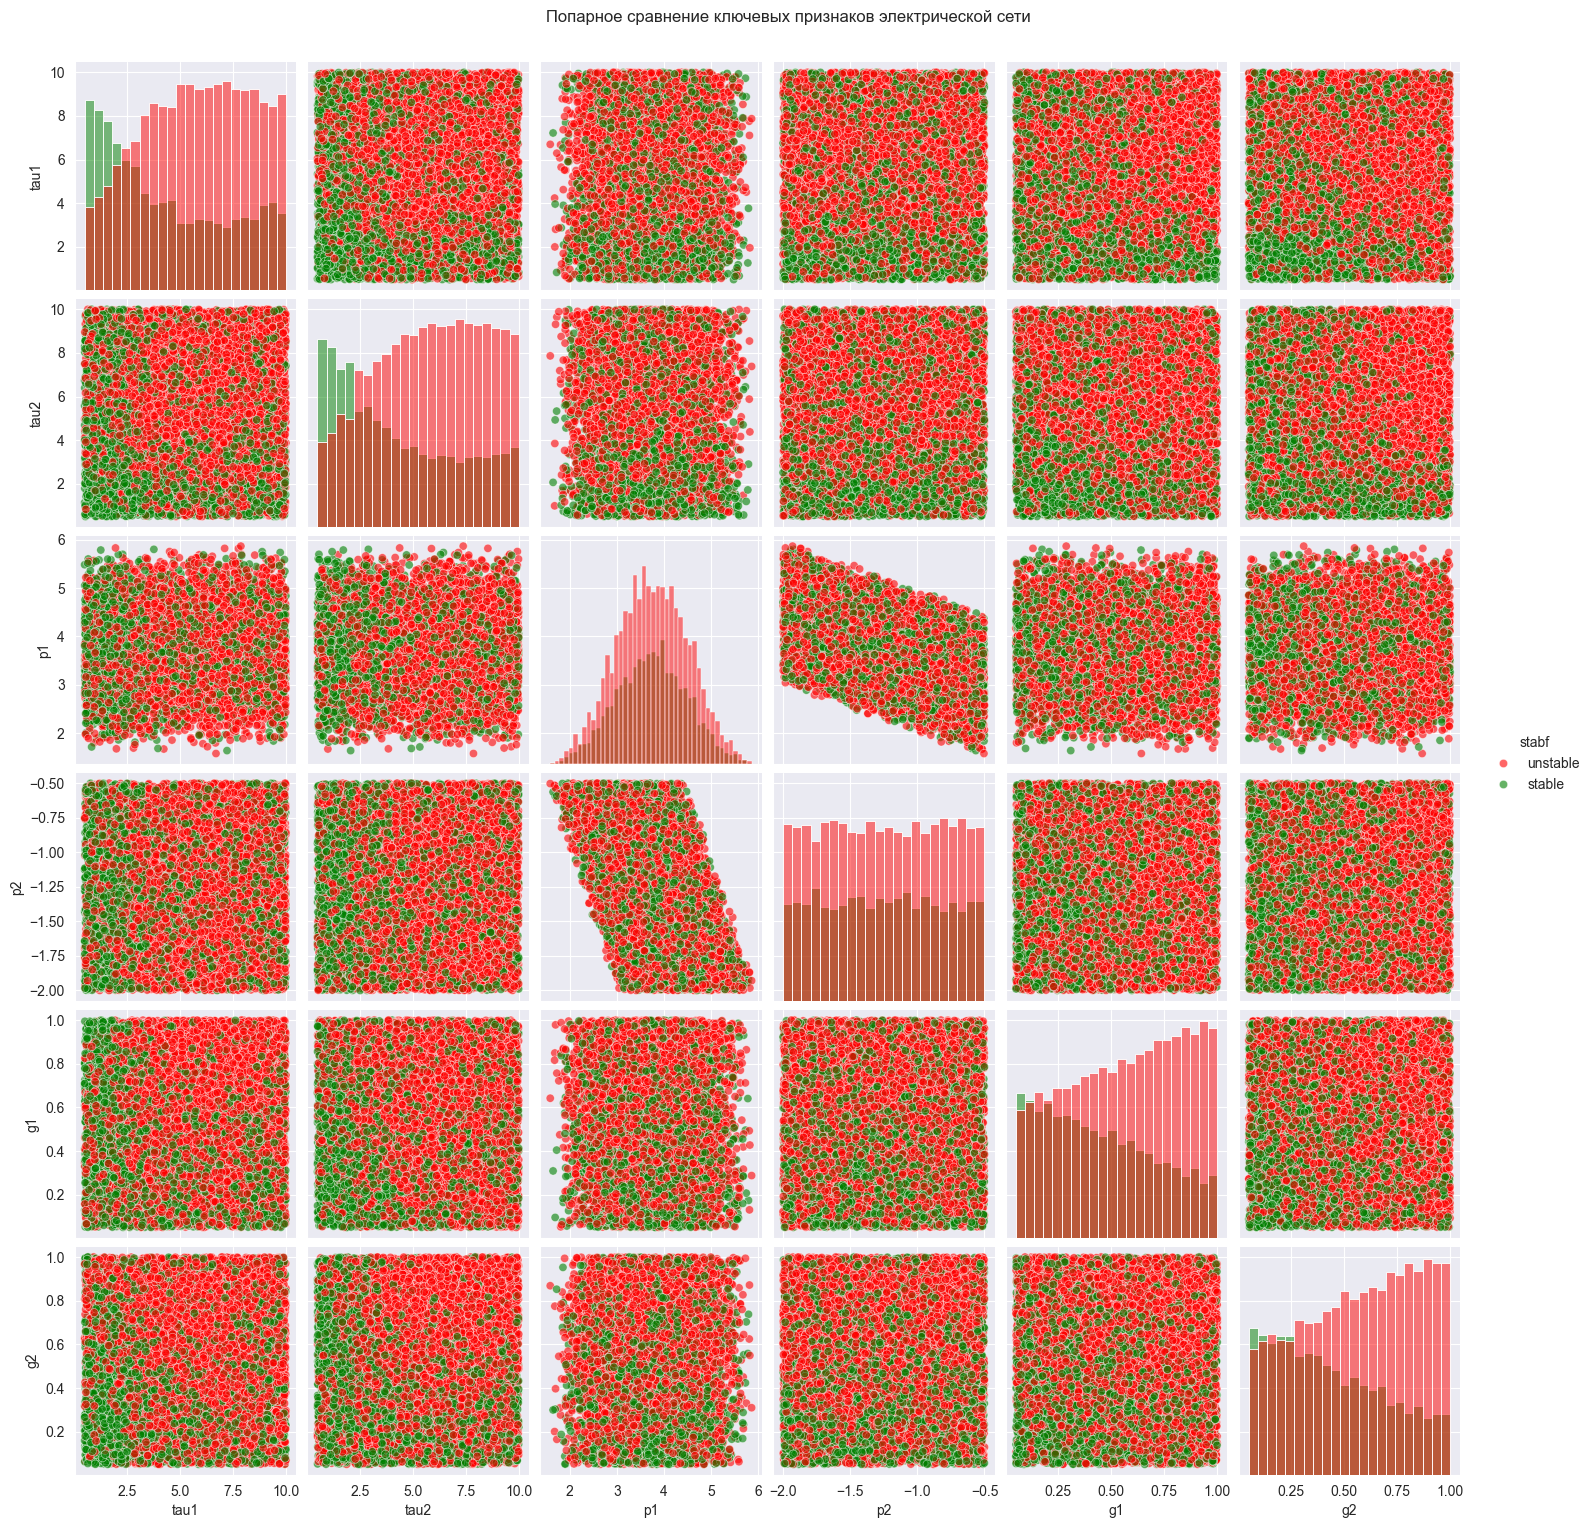

In [14]:
# подмножество признаков
selected_features = ['tau1', 'tau2', 'p1', 'p2', 'g1', 'g2', 'stabf']

sns.pairplot(df[selected_features],
             hue='stabf',
             palette={'stable': 'green', 'unstable': 'red'},
             diag_kind='hist',
             plot_kws={'alpha': 0.6})

plt.suptitle('Попарное сравнение ключевых признаков электрической сети', y=1.02)
plt.show()

Анализ взаимосвязи мощности и ценовой эластичности узла-поставщика
Исследует зависимость между номинальной мощностью и коэффициентом ценовой эластичности основного поставщика энергии. Цвет точек указывает на стабильность сети.

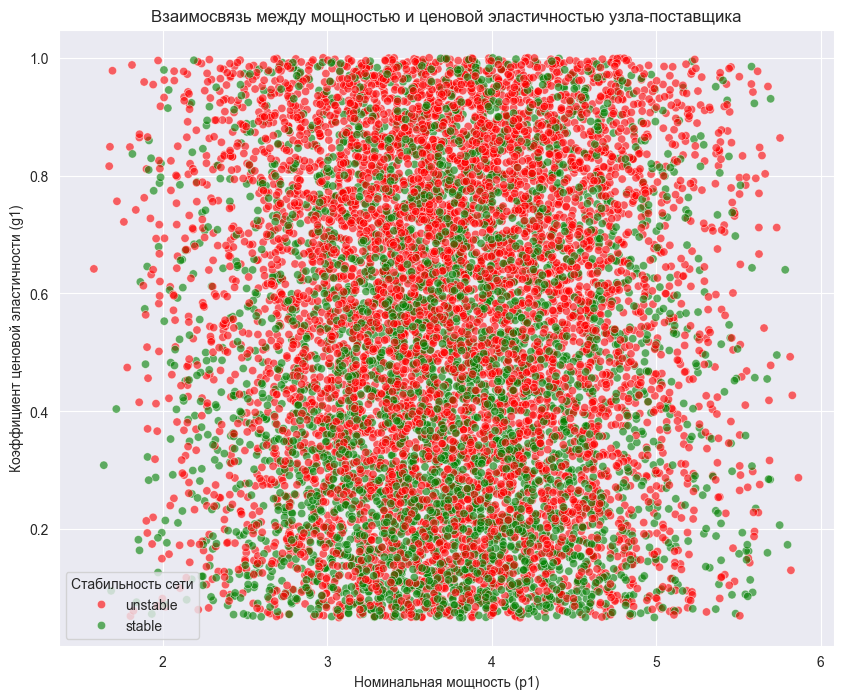

In [15]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='p1', y='g1', hue='stabf',
                palette={'stable': 'green', 'unstable': 'red'}, alpha=0.6)
plt.title('Взаимосвязь между мощностью и ценовой эластичностью узла-поставщика')
plt.xlabel('Номинальная мощность (p1)')
plt.ylabel('Коэффициент ценовой эластичности (g1)')
plt.legend(title='Стабильность сети')
plt.show()

**7. Корреляция признаков**

Тепловая карта матрицы корреляции признаков
Визуализирует попарные корреляции между всеми числовыми признаками набора данных. Цветовая шкала от синего до красного идентифицирует сильные положительные и отрицательные взаимосвязи, а числовые аннотации предоставляют точные значения коэффициентов корреляции Пирсона для количественной оценки зависимостей между параметрами системы.

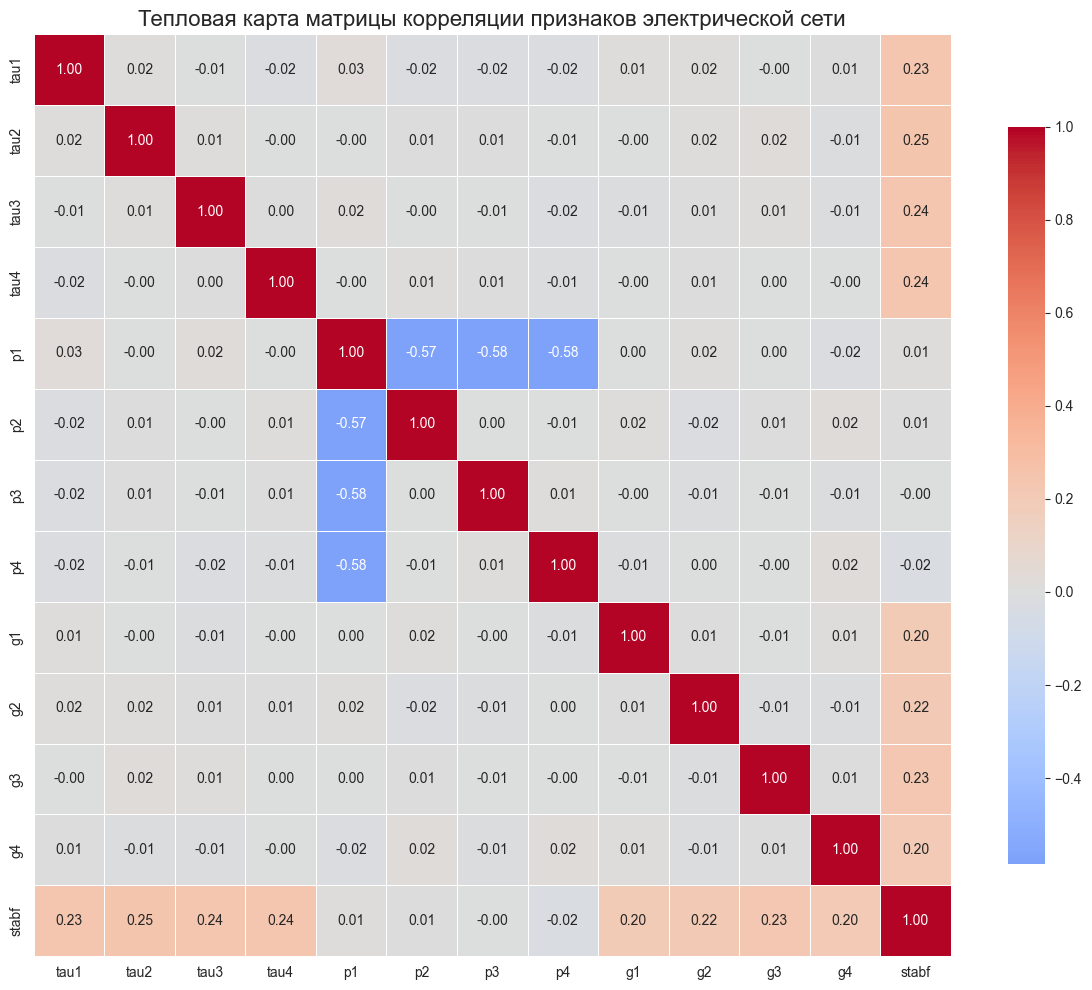

In [16]:
df_numeric = df.copy()
df_numeric['stabf'] = df_numeric['stabf'].map({'stable': 0, 'unstable': 1})

plt.figure(figsize=(12, 10))
correlation_matrix = df_numeric.corr()

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Тепловая карта матрицы корреляции признаков электрической сети', fontsize=16)
plt.tight_layout()
plt.show()

Анализ корреляции признаков с целевой переменной стабильности
Определяет и ранжирует признаки по степени их влияния на стабильность электрической сети через вычисление коэффициентов корреляции. Числовой вывод предоставляет количественную оценку значимости каждого параметра, визуализация в виде матрицы ящиков с усами.

Корреляция признаков со стабильностью сети:
tau2 (Время реакции узла-потребителя 1): 0.246
tau4 (Время реакции узла-потребителя 3): 0.239
tau3 (Время реакции узла-потребителя 2): 0.237
tau1 (Время реакции узла-поставщика): 0.235
g3 (Коэффициент ценовой эластичности узла-потребителя 2): 0.232
g2 (Коэффициент ценовой эластичности узла-потребителя 1): 0.217
g4 (Коэффициент ценовой эластичности узла-потребителя 3): 0.205
g1 (Коэффициент ценовой эластичности узла-поставщика): 0.198
p1 (Номинальная мощность узла-поставщика): 0.010
p2 (Номинальная мощность узла-потребителя 1): 0.006
p3 (Номинальная мощность узла-потребителя 2): -0.001
p4 (Номинальная мощность узла-потребителя 3): -0.023


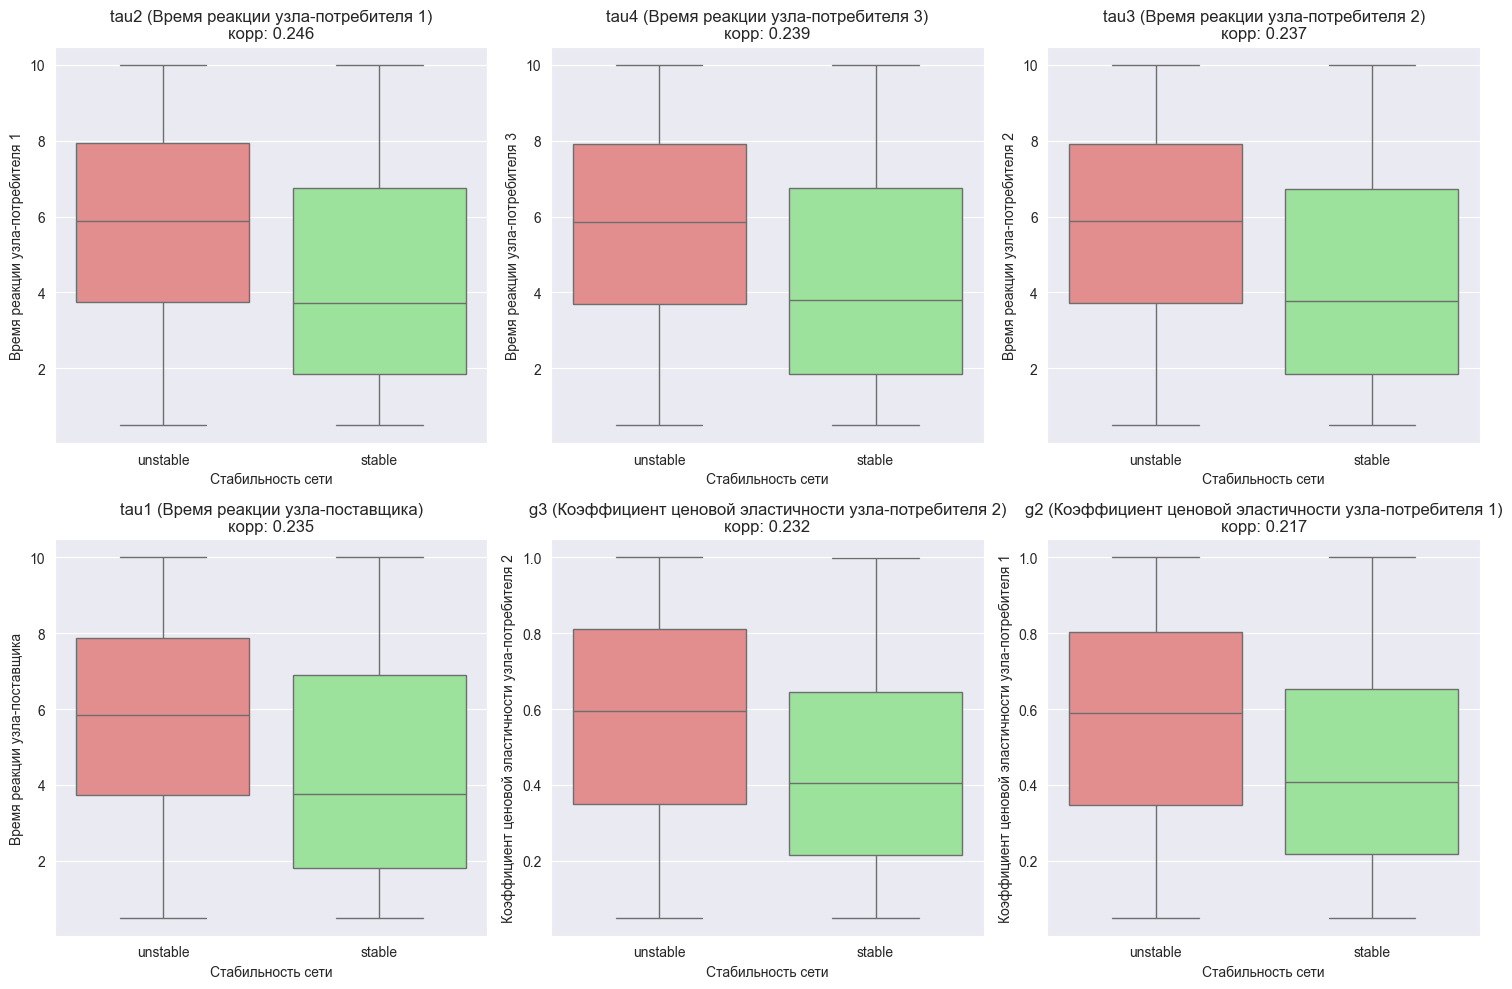

In [21]:
df_numeric = df.copy()
df_numeric['stabf'] = df_numeric['stabf'].map({'stable': 0, 'unstable': 1})

correlation_with_target = df_numeric.corr()['stabf'].sort_values(ascending=False)

print("Корреляция признаков со стабильностью сети:")
for feature, corr in correlation_with_target.items():
    if feature != 'stabf':
        feature_name = get_feature_russian_name(feature)
        print(f"{feature} ({feature_name}): {corr:.3f}")

top_features = correlation_with_target[1:7].index

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    sns.boxplot(data=df, x='stabf', y=feature, hue='stabf', ax=axes[i],
                palette={'stable': 'lightgreen', 'unstable': 'lightcoral'},
                legend=False)

    feature_name = get_feature_russian_name(feature)
    axes[i].set_title(f'{feature} ({feature_name})\nкорр: {correlation_with_target[feature]:.3f}')
    axes[i].set_xlabel('Стабильность сети')
    axes[i].set_ylabel(feature_name)

plt.tight_layout()
plt.show()

**8. Дополнительная визуализация**

График скрипки для распределения номинальной мощности узла-поставщика
Ширина графика отражает плотность вероятности в разных диапазонах значений

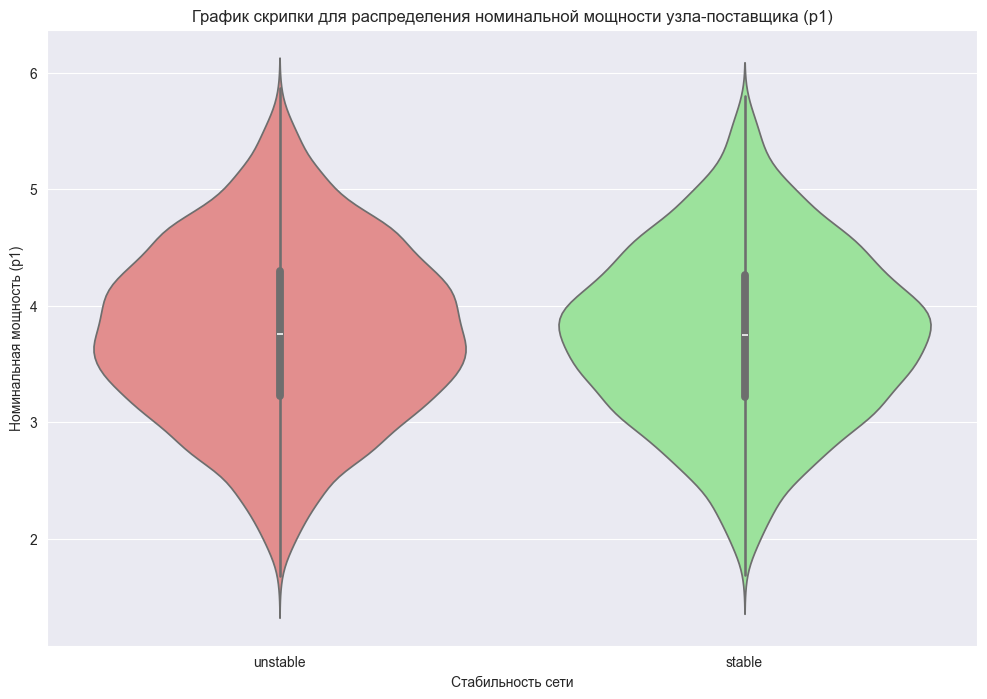

In [22]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=df, x='stabf', y='p1', hue='stabf',
               palette={'stable': 'lightgreen', 'unstable': 'lightcoral'},
               legend=False)
plt.title('График скрипки для распределения номинальной мощности узла-поставщика (p1)')
plt.xlabel('Стабильность сети')
plt.ylabel('Номинальная мощность (p1)')
plt.show()

Сравнительное распределение времени реакции по состояниям стабильности

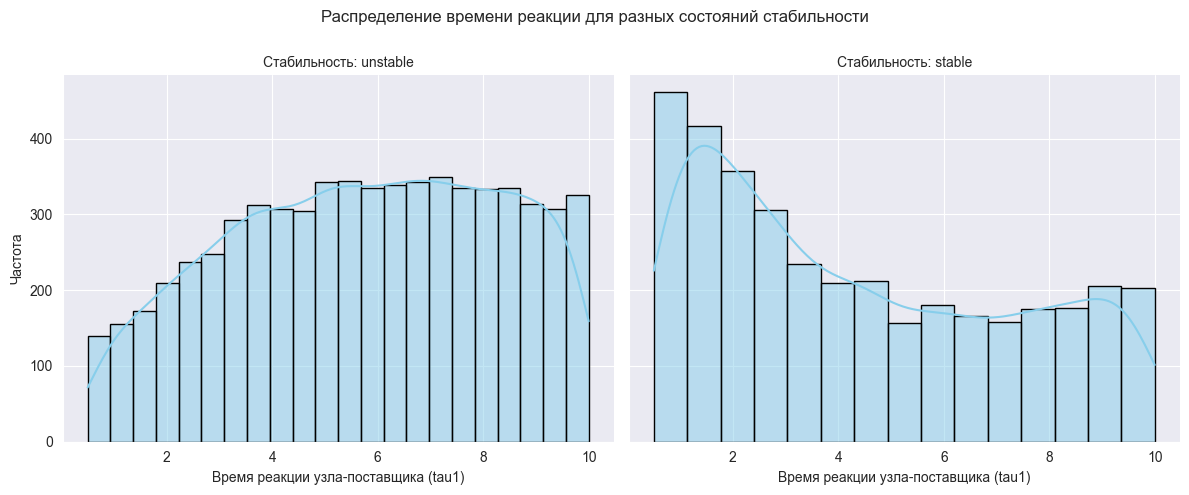

In [19]:
g = sns.FacetGrid(df, col='stabf', height=5, aspect=1.2)
g.map(sns.histplot, 'tau1', kde=True, color='skyblue', edgecolor='black')
g.set_titles('Стабильность: {col_name}')
g.set_axis_labels('Время реакции узла-поставщика (tau1)', 'Частота')

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Распределение времени реакции для разных состояний стабильности')
plt.show()